<center><h2 style="color:#0000ff; font-family:Georgia;"><b>DATA 645. Neural Networks and Deep Learning</b></h2>
<h2 style="color:#ff0000; font-family:'Calibri';">Module 7 Homework Lab</h2>
<h1 style="color:#9933cc; font-family:Arial;"><b>Neural Network Training, Refinement, and Regularization<br></b></h1></center>


The objective of this lab assignment is to familiarize yourself with building, training, and evaluating neural network models for binary classification tasks using the IMDB dataset. 

## Tasks

#### 1. Data Loading and Preprocessing:   
   - Load the IMDB dataset using TensorFlow Keras and understand its structure.
   - Preprocess the dataset by performing multi-hot encoding to convert it into a format suitable for neural network input.
   

#### 2. Model Building and Compilation:  
   - Build a neural network model with appropriate layers for binary classification.
   - Compile the model with suitable loss function, optimizer, and evaluation metric.
   

#### 3. Model Training and Validation:  
   - Split the dataset into training and validation sets.
   - Train the model on the training set and validate it using the validation set.
   - Monitor the training process by observing the changes in training and validation loss and accuracy across epochs.
   

#### 4. Model Evaluation:  
   - Evaluate the trained model's performance on the test set.
   - Analyze the obtained results in terms of accuracy and loss.
   

#### 5. Model Refinement and Retraining:  
   - Based on the evaluation results, refine the model architecture if necessary.
   - Retrain the model from scratch with the refined architecture.
   - Evaluate the performance of the retrained model on the test set and compare it with the previous results.
   
#### 6. Regularization and Optimization  
   - Experiment with different neural network architectures (e.g., changing the number of layers, units per layer, activation functions) and observe their impact on model performance.
   - Explore advanced techniques such as dropout, batch normalization, or different optimizers to improve model generalization and performance.

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

%load_ext tensorboard

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

#1 Data Loading and Preprocessing

In [3]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

In [4]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [5]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [9]:
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"x_test shape:  {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (20000, 10000)
X_valid shape: (5000, 10000)
x_test shape:  (25000, 10000)
y_train shape: (20000,)
y_valid shape: (5000,)
y_test shape:  (25000,)


# 2. Model Building and Compilation

In [10]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(2, activation="sigmoid")
])

In [11]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

# 3. Model Training and Validation

In [12]:
movies_1 = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6463 - loss: 0.5948 - val_accuracy: 0.8302 - val_loss: 0.4897
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8920 - loss: 0.3681 - val_accuracy: 0.8772 - val_loss: 0.3347
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9303 - loss: 0.2302 - val_accuracy: 0.8826 - val_loss: 0.2972
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9495 - loss: 0.1723 - val_accuracy: 0.8830 - val_loss: 0.2954
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9622 - loss: 0.1375 - val_accuracy: 0.8828 - val_loss: 0.3043
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9712 - loss: 0.1117 - val_accuracy: 0.8800 - val_loss: 0.3196
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9785 - loss: 0.0908 - val_accuracy: 0.8798 - val_loss: 0.3391
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0735 - val_accuracy: 0.

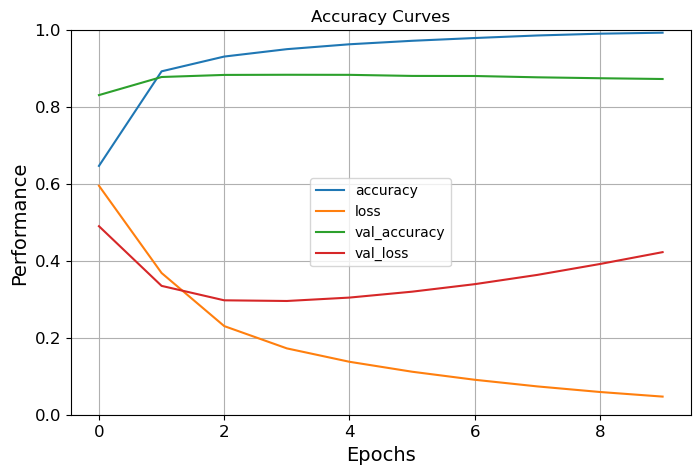

In [15]:
import pandas as pd
pd.DataFrame(movies_1.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.xlabel("Epochs")
plt.ylabel("Performance")
plt.title("Accuracy Curves")
plt.show()

The training accuracy increases dramatically, from .6463 on the first epoch to .9923 on the 10th epoch. However, the validation accuracy does not improve much. It goes from .8302 in the first epoc and .8720 in the 10th epoch. It actually peakes in the 4th epoch at .8830. We appear to be overfitting the data.


#4. Model Evaluation

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8655 - loss: 0.4320
Test Loss: 0.4320
Test Accuracy: 0.8655


The test accuracy is 0.8655. Again, this is a big difference with the training accuracy. The loss is 0.4320, which is again a big difference from training loss (0.0471). All this implies overfitting has occured.

# 5. Model Refinement and Retraining

In [18]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers

model_reg = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(2, activation="sigmoid")
])

In [22]:
model_reg.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])

In [23]:
movies_2 = model_reg.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6891 - loss: 0.6429 - val_accuracy: 0.8502 - val_loss: 0.4795
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8400 - loss: 0.4496 - val_accuracy: 0.8796 - val_loss: 0.3698
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8892 - loss: 0.3548 - val_accuracy: 0.8866 - val_loss: 0.3349
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9060 - loss: 0.3066 - val_accuracy: 0.8896 - val_loss: 0.3227
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9222 - loss: 0.2707 - val_accuracy: 0.8908 - val_loss: 0.3211
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9340 - loss: 0.2463 - val_accuracy: 0.8916 - val_loss: 0.3257
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9438 - loss: 0.2229 - val_accuracy: 0.8888 - val_loss: 0.3348
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9517 - loss: 0.2056 - val_accuracy: 0.

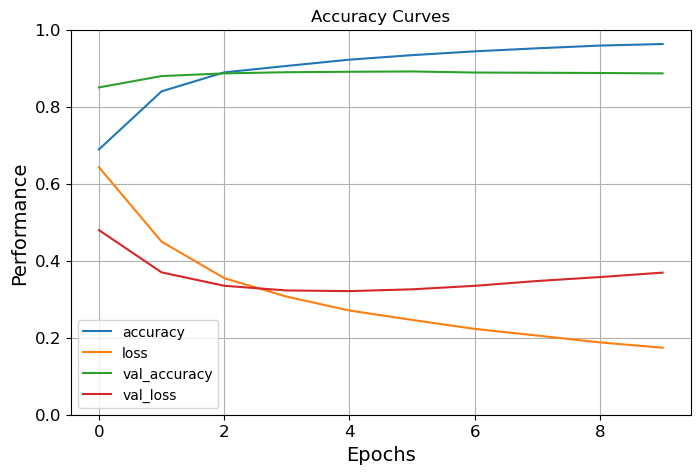

In [24]:
pd.DataFrame(movies_2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.xlabel("Epochs")
plt.ylabel("Performance")
plt.title("Accuracy Curves")
plt.show()


This is bettter, but the accuracy and validation loss are still relatively stubborn, not improving with increased training.

# 6. Regularization and Optimization

In [26]:
model_reg_2 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(2, activation="softmax")
])

In [29]:
model_reg_2.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])

In [30]:
movies_3 = model_reg_2.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6591 - loss: 0.6495 - val_accuracy: 0.8482 - val_loss: 0.5106
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8177 - loss: 0.4711 - val_accuracy: 0.8778 - val_loss: 0.3943
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8778 - loss: 0.3801 - val_accuracy: 0.8826 - val_loss: 0.3547
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9028 - loss: 0.3307 - val_accuracy: 0.8860 - val_loss: 0.3368
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9238 - loss: 0.2885 - val_accuracy: 0.8884 - val_loss: 0.3308
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9357 - loss: 0.2615 - val_accuracy: 0.8870 - val_loss: 0.3298
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9452 - loss: 0.2311 - val_accuracy: 0.8876 - val_loss: 0.3356
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9532 - loss: 0.2142 - val_accuracy: 0.

In [ ]:
# Adding nodes, now that we are robust against overfitting
model_reg_3 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(25, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(2, activation="softmax")
])
model_reg_3.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_4 = model_reg_3.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7538 - loss: 0.6286 - val_accuracy: 0.8720 - val_loss: 0.4499
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8823 - loss: 0.4093 - val_accuracy: 0.8846 - val_loss: 0.3803
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9143 - loss: 0.3289 - val_accuracy: 0.8886 - val_loss: 0.3659
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9330 - loss: 0.2773 - val_accuracy: 0.8886 - val_loss: 0.3679
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9463 - loss: 0.2440 - val_accuracy: 0.8856 - val_loss: 0.3749
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9552 - loss: 0.2176 - val_accuracy: 0.8862 - val_loss: 0.3923
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9672 - loss: 0.1919 - val_accuracy: 0.8852 - val_loss: 0.4037
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9733 - loss: 0.1734 - val_accuracy: 0.

Good performance overall on validation. But still there is a gulf between train and validation.

In [ ]:
# Simplified model.
model_reg_4 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(2, activation="softmax")
])
model_reg_4.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_5 = model_reg_4.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6330 - loss: 0.6438 - val_accuracy: 0.7082 - val_loss: 0.5795
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7963 - loss: 0.5372 - val_accuracy: 0.8050 - val_loss: 0.5137
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8644 - loss: 0.4772 - val_accuracy: 0.8408 - val_loss: 0.4750
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8944 - loss: 0.4360 - val_accuracy: 0.8596 - val_loss: 0.4479
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9090 - loss: 0.4033 - val_accuracy: 0.8648 - val_loss: 0.4283
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9203 - loss: 0.3755 - val_accuracy: 0.8746 - val_loss: 0.4108
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9274 - loss: 0.3521 - val_accuracy: 0.8752 - val_loss: 0.3987
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9327 - loss: 0.3304 - val_accuracy: 0.

Training is closer to testing here, but training accuracy has dropped.

In [ ]:
# Deeper Model
model_reg_5 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(5, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(2, activation="softmax")
])
model_reg_5.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_6 = model_reg_5.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5403 - loss: 0.7281 - val_accuracy: 0.6988 - val_loss: 0.7024
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6173 - loss: 0.6938 - val_accuracy: 0.8176 - val_loss: 0.6487
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6699 - loss: 0.6596 - val_accuracy: 0.8482 - val_loss: 0.5865
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7031 - loss: 0.6332 - val_accuracy: 0.8634 - val_loss: 0.5410
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7359 - loss: 0.6012 - val_accuracy: 0.8736 - val_loss: 0.5029
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7703 - loss: 0.5636 - val_accuracy: 0.8766 - val_loss: 0.4623
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8062 - loss: 0.5244 - val_accuracy: 0.8752 - val_loss: 0.4393
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8288 - loss: 0.4830 - val_accuracy: 0.

The training and testing accuracy are worse with a deep model.

In [ ]:
# Changing to binary classifier.
model_reg_6 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.25),
    keras.layers.Dense(1, activation="sigmoid")
])
model_reg_6.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_6 = model_reg_6.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6956 - loss: 0.6294 - val_accuracy: 0.8514 - val_loss: 0.4679
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8431 - loss: 0.4408 - val_accuracy: 0.8744 - val_loss: 0.3725
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8837 - loss: 0.3584 - val_accuracy: 0.8814 - val_loss: 0.3382
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9045 - loss: 0.3140 - val_accuracy: 0.8872 - val_loss: 0.3258
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9211 - loss: 0.2789 - val_accuracy: 0.8886 - val_loss: 0.3217
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9312 - loss: 0.2493 - val_accuracy: 0.8872 - val_loss: 0.3273
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9398 - loss: 0.2317 - val_accuracy: 0.8878 - val_loss: 0.3319
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9473 - loss: 0.2135 - val_accuracy: 0.

In [40]:
# Increasing number of nodes for binary classifier.
# Increasing l2 penality as well.
model_reg_7 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.25),
    keras.layers.Dense(25, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.25),
    keras.layers.Dense(1, activation="sigmoid")
])
model_reg_7.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_7 = model_reg_7.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6463 - loss: 1.3383 - val_accuracy: 0.8470 - val_loss: 0.9189
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8414 - loss: 0.7953 - val_accuracy: 0.8746 - val_loss: 0.6708
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8751 - loss: 0.6198 - val_accuracy: 0.8782 - val_loss: 0.5694
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8908 - loss: 0.5294 - val_accuracy: 0.8808 - val_loss: 0.5105
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9000 - loss: 0.4703 - val_accuracy: 0.8836 - val_loss: 0.4745
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9054 - loss: 0.4314 - val_accuracy: 0.8814 - val_loss: 0.4517
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9086 - loss: 0.4071 - val_accuracy: 0.8824 - val_loss: 0.4362
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9124 - loss: 0.3873 - val_accuracy: 0.

Slightly higher accuracy consistently accross epochs.

In [ ]:
# Increasing layers and dropout.
model_reg_8 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    keras.layers.Dense(25, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    keras.layers.Dense(25, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")
])
model_reg_8.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_8 = model_reg_8.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5334 - loss: 2.7603 - val_accuracy: 0.7748 - val_loss: 2.2555
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6436 - loss: 1.9365 - val_accuracy: 0.8398 - val_loss: 1.6023
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7589 - loss: 1.4335 - val_accuracy: 0.8626 - val_loss: 1.1705
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8400 - loss: 1.0890 - val_accuracy: 0.8766 - val_loss: 0.9004
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8758 - loss: 0.8652 - val_accuracy: 0.8786 - val_loss: 0.7485
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8932 - loss: 0.7166 - val_accuracy: 0.8796 - val_loss: 0.6459
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9004 - loss: 0.6157 - val_accuracy: 0.8784 - val_loss: 0.5829
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9130 - loss: 0.5401 - val_accuracy: 0

Not as good as the previous model.

In [45]:
# Increasing number of nodes.
# Increasing dropout  penality.
model_reg_9 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.4),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.4),
    keras.layers.Dense(1, activation="sigmoid")
])
model_reg_9.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_9 = model_reg_9.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7181 - loss: 1.9356 - val_accuracy: 0.8616 - val_loss: 1.1777
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8634 - loss: 0.9743 - val_accuracy: 0.8740 - val_loss: 0.7902
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8885 - loss: 0.6948 - val_accuracy: 0.8792 - val_loss: 0.6200
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8938 - loss: 0.5568 - val_accuracy: 0.8814 - val_loss: 0.5312
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9047 - loss: 0.4715 - val_accuracy: 0.8812 - val_loss: 0.4799
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9082 - loss: 0.4275 - val_accuracy: 0.8804 - val_loss: 0.4514
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9096 - loss: 0.3998 - val_accuracy: 0.8846 - val_loss: 0.4359
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9140 - loss: 0.3797 - val_acc

Best performance so far.

In [44]:
# Adding a layer.
# Increasing dropout and L2 penality.
model_reg_10 = keras.models.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(200, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.05)),
    Dropout(0.5),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.05)),
    Dropout(0.5),
    keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(0.05)),
    Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")
])
model_reg_10.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"])
movies_10 = model_reg_10.fit(X_train, y_train, epochs=10, validation_data= (X_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6222 - loss: 14.0469 - val_accuracy: 0.8274 - val_loss: 6.9342
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7952 - loss: 4.7371 - val_accuracy: 0.8494 - val_loss: 3.0634
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8257 - loss: 2.2032 - val_accuracy: 0.8476 - val_loss: 1.5186
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8353 - loss: 1.1957 - val_accuracy: 0.8548 - val_loss: 0.9218
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8413 - loss: 0.8158 - val_accuracy: 0.8548 - val_loss: 0.7047
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8454 - loss: 0.6793 - val_accuracy: 0.8590 - val_loss: 0.6300
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8486 - loss: 0.6308 - val_accuracy: 0.8586 - val_loss: 0.6014
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8492 - loss: 0.6131 -

Performance got worse. We will use the previous model.

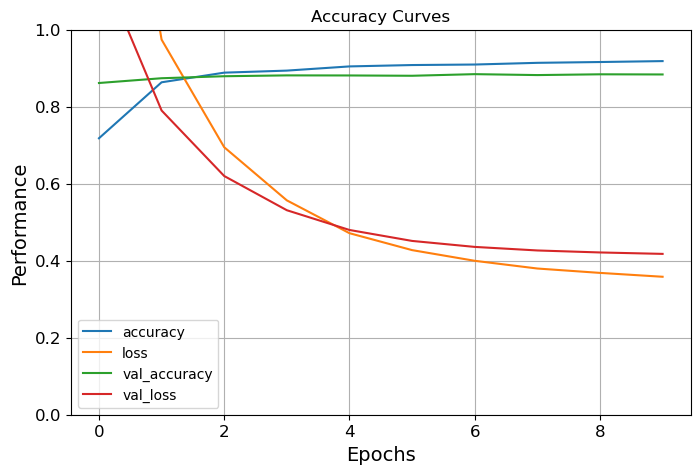

In [46]:
pd.DataFrame(movies_9.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.xlabel("Epochs")
plt.ylabel("Performance")
plt.title("Accuracy Curves")
plt.show()